In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import os
import numpy as np

In [2]:
results = [] # File Loading

path = '/Users/darrinobrien/Desktop/School/Summer_Programs/Ongoing/Algoverse/Vision/CLIP/DTD/Ablation_Testing/Results'

try:
    for filename in os.listdir(path):
        if filename == ".DS_Store":
            continue
        file_path = os.path.join(path, filename)
        if os.path.isfile(file_path):
            results.append(file_path)
except FileNotFoundError:
    print(f"Error: The Folder '{path}' was not found.")
except Exception as e:
    print(f"An error occured: {e}")

In [ ]:
len(results) # Should be 1. Sanity Check

1

In [8]:
data[0].loc[2, "Co_Sim_CLS"]

0.1664485531548659

In [10]:
layers = {}
for i in range(12):
    layers[i] = []
    for j in range(12):
        layers[i].append(j)

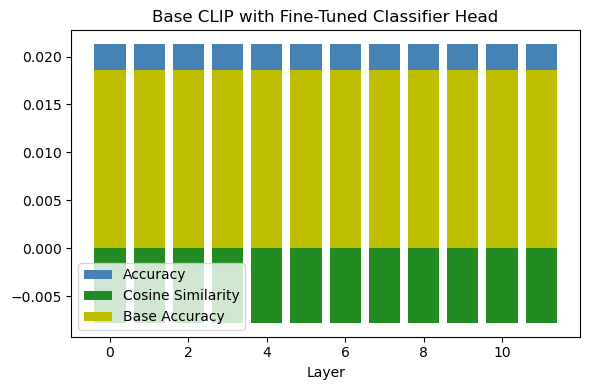

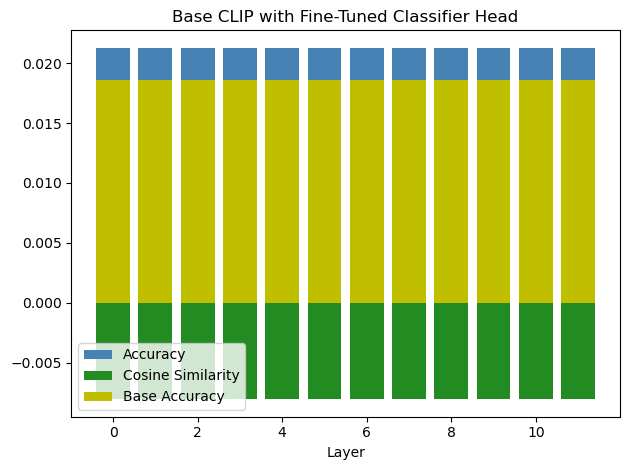

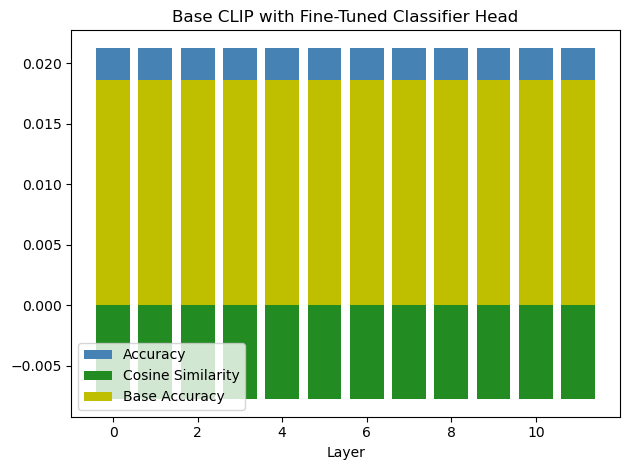

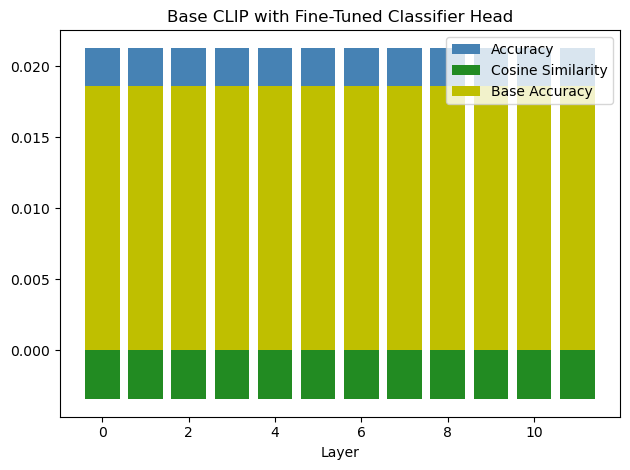

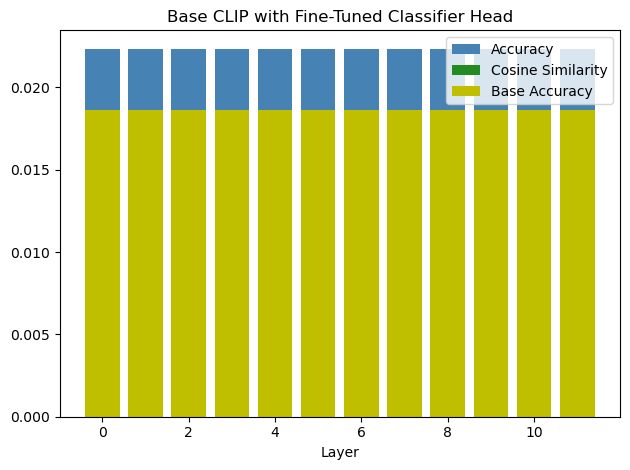

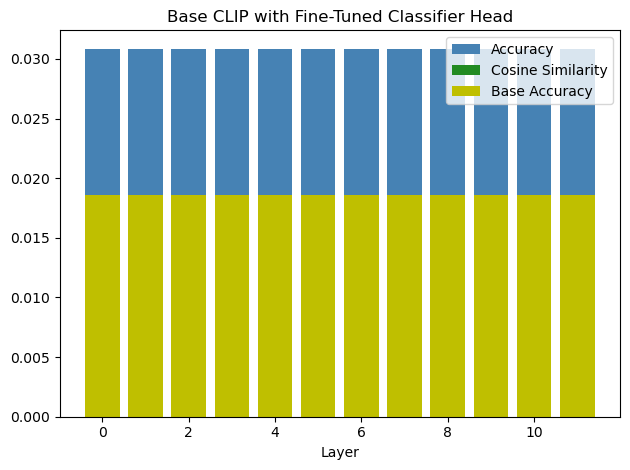

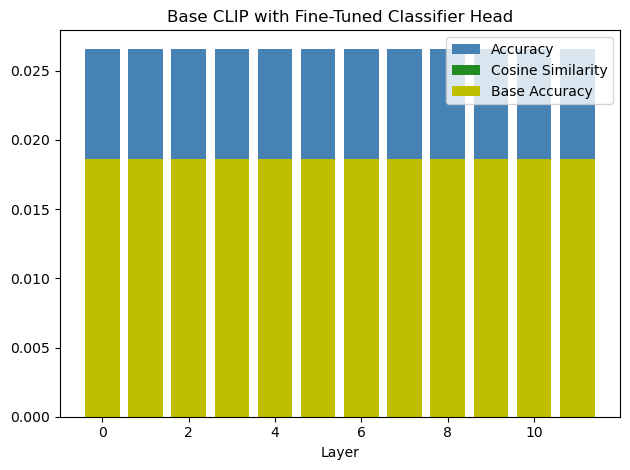

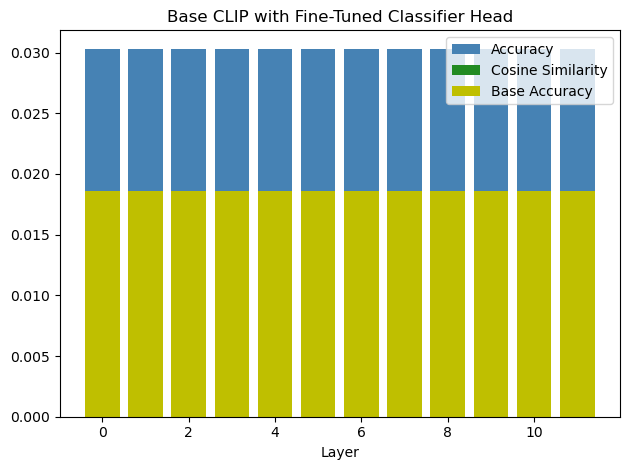

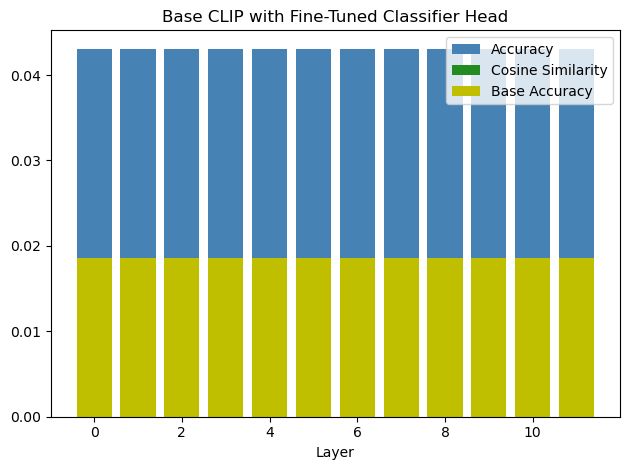

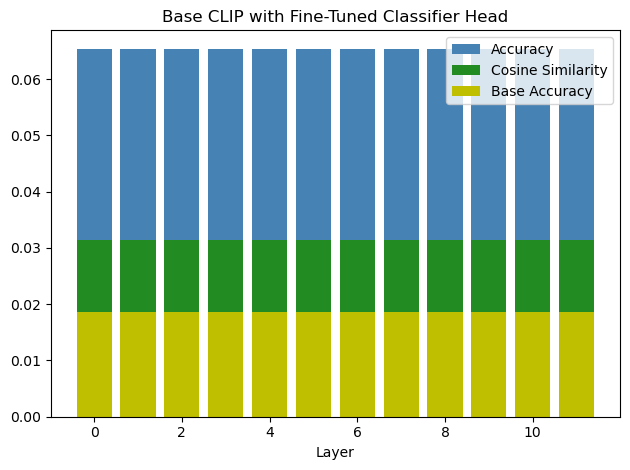

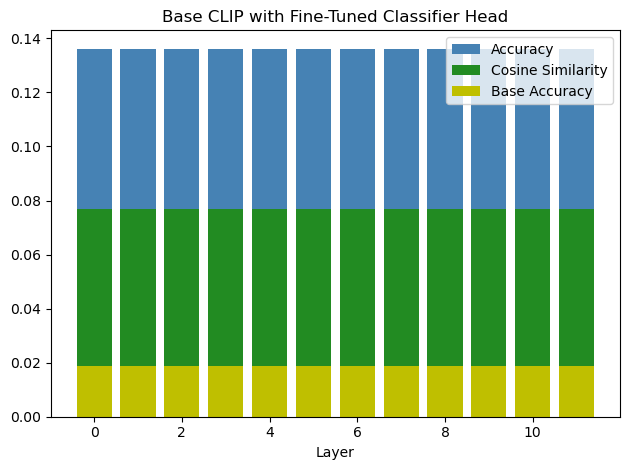

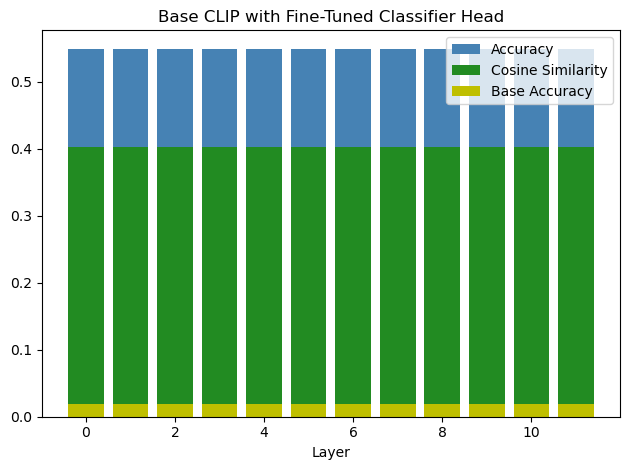

In [18]:
plt.figure(figsize=(6,4))
for i in range(12):
    acc = []
    co_sim_cls = []
    acc.append(data[0].loc[i, "Accuracy"])
    co_sim_cls.append(data[0].loc[i, "Co_Sim_CLS"])
    plt.bar(layers[i], acc, color="steelblue", label="Accuracy")
    plt.bar(layers[i], co_sim_cls, color="forestgreen", label="Cosine Similarity")
    # plt.bar(layers[i], 0.7633, label="Fine-Tuned Accuracy")
    plt.bar(layers[i], 0.0186, color="y", label="Base Accuracy")
    plt.legend()
    plt.title(f"Base CLIP with Fine-Tuned Classifier Head")
    plt.xlabel("Layer")
    plt.tight_layout()
    plt.show()

In [21]:
acc = []
co_sim_cls = []

for i in range(12):
    acc.append(data[0].loc[i, "Accuracy"])
    co_sim_cls.append(data[0].loc[i, "Co_Sim_CLS"])

for i in range(12):
    print(f"Layer {i}")
    print(f"Accuracy: {acc[i]}")
    print(f"Cosine Similarty: {co_sim_cls[i]}")


Layer 0
Accuracy: 0.0212765957446808
Cosine Similarty: -0.0077505039749667
Layer 1
Accuracy: 0.0212765957446808
Cosine Similarty: -0.0080421554196315
Layer 2
Accuracy: 0.0212765957446808
Cosine Similarty: -0.0077565617548922
Layer 3
Accuracy: 0.0212765957446808
Cosine Similarty: -0.0034542061466102
Layer 4
Accuracy: 0.0223404255319148
Cosine Similarty: 0.0012417477671988
Layer 5
Accuracy: 0.0308510638297872
Cosine Similarty: 0.007561010424979
Layer 6
Accuracy: 0.026595744680851
Cosine Similarty: 0.0106394939240999
Layer 7
Accuracy: 0.0303191489361702
Cosine Similarty: 0.0141533632141848
Layer 8
Accuracy: 0.0430851063829787
Cosine Similarty: 0.0104947355032588
Layer 9
Accuracy: 0.0654255319148936
Cosine Similarty: 0.0313853718029956
Layer 10
Accuracy: 0.1361702127659574
Cosine Similarty: 0.076841951534152
Layer 11
Accuracy: 0.548936170212766
Cosine Similarty: 0.4021686712900797


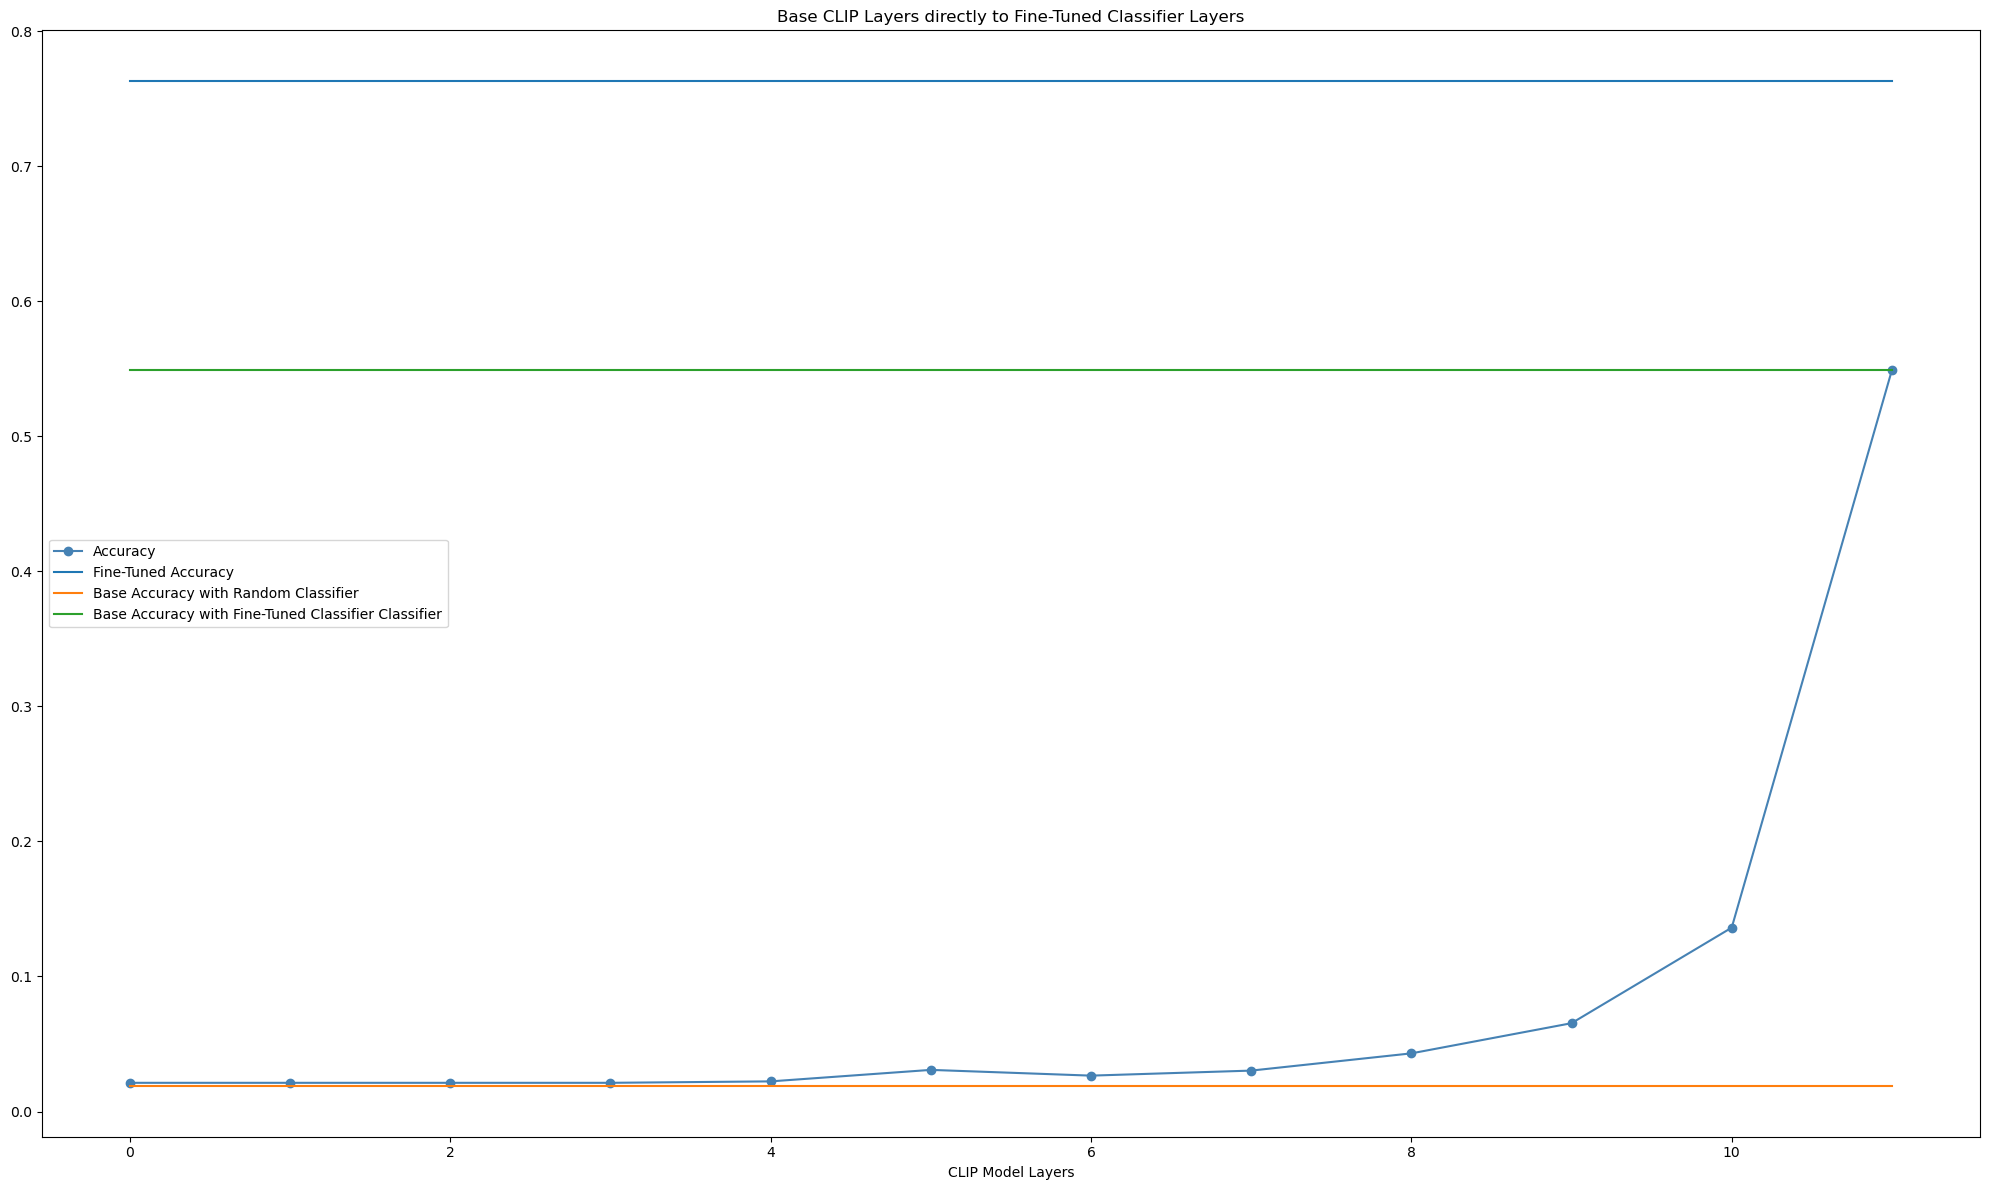

In [ ]:
fine_tuned = [0.7633] * 12
base_fine = [0.5489] * 12
base_base = [0.0186] * 12

# Base Accuracy: 0.0186
plt.figure(figsize=(20, 12))
plt.plot([i for i in range(12)], acc, marker="o", color="steelblue", label="Accuracy")
# plt.plot([i for i in range(12)], co_sim_cls, marker="o", color="forestgreen", label="Cosine Similarity")
plt.plot([i for i in range(12)], fine_tuned, label="Fine-Tuned Accuracy")
plt.plot([i for i in range(12)], base_base, label="Base Accuracy with Random Classifier")
plt.plot([i for i in range(12)], base_fine, label="Base Accuracy with Fine-Tuned Classifier Classifier")
plt.legend()
plt.title("Base CLIP Layers directly to Fine-Tuned Classifier Layers")
plt.xlabel("CLIP Model Layers")
plt.tight_layout()
plt.savefig(f'/Users/darrinobrien/Desktop/School/Summer_Programs/Ongoing/Algoverse/Vision/CLIP/DTD/Ablation_Testing/Graphed_Results/All_Augmented_Layers_Classifiction_Accuracy', dpi=600)
plt.show()

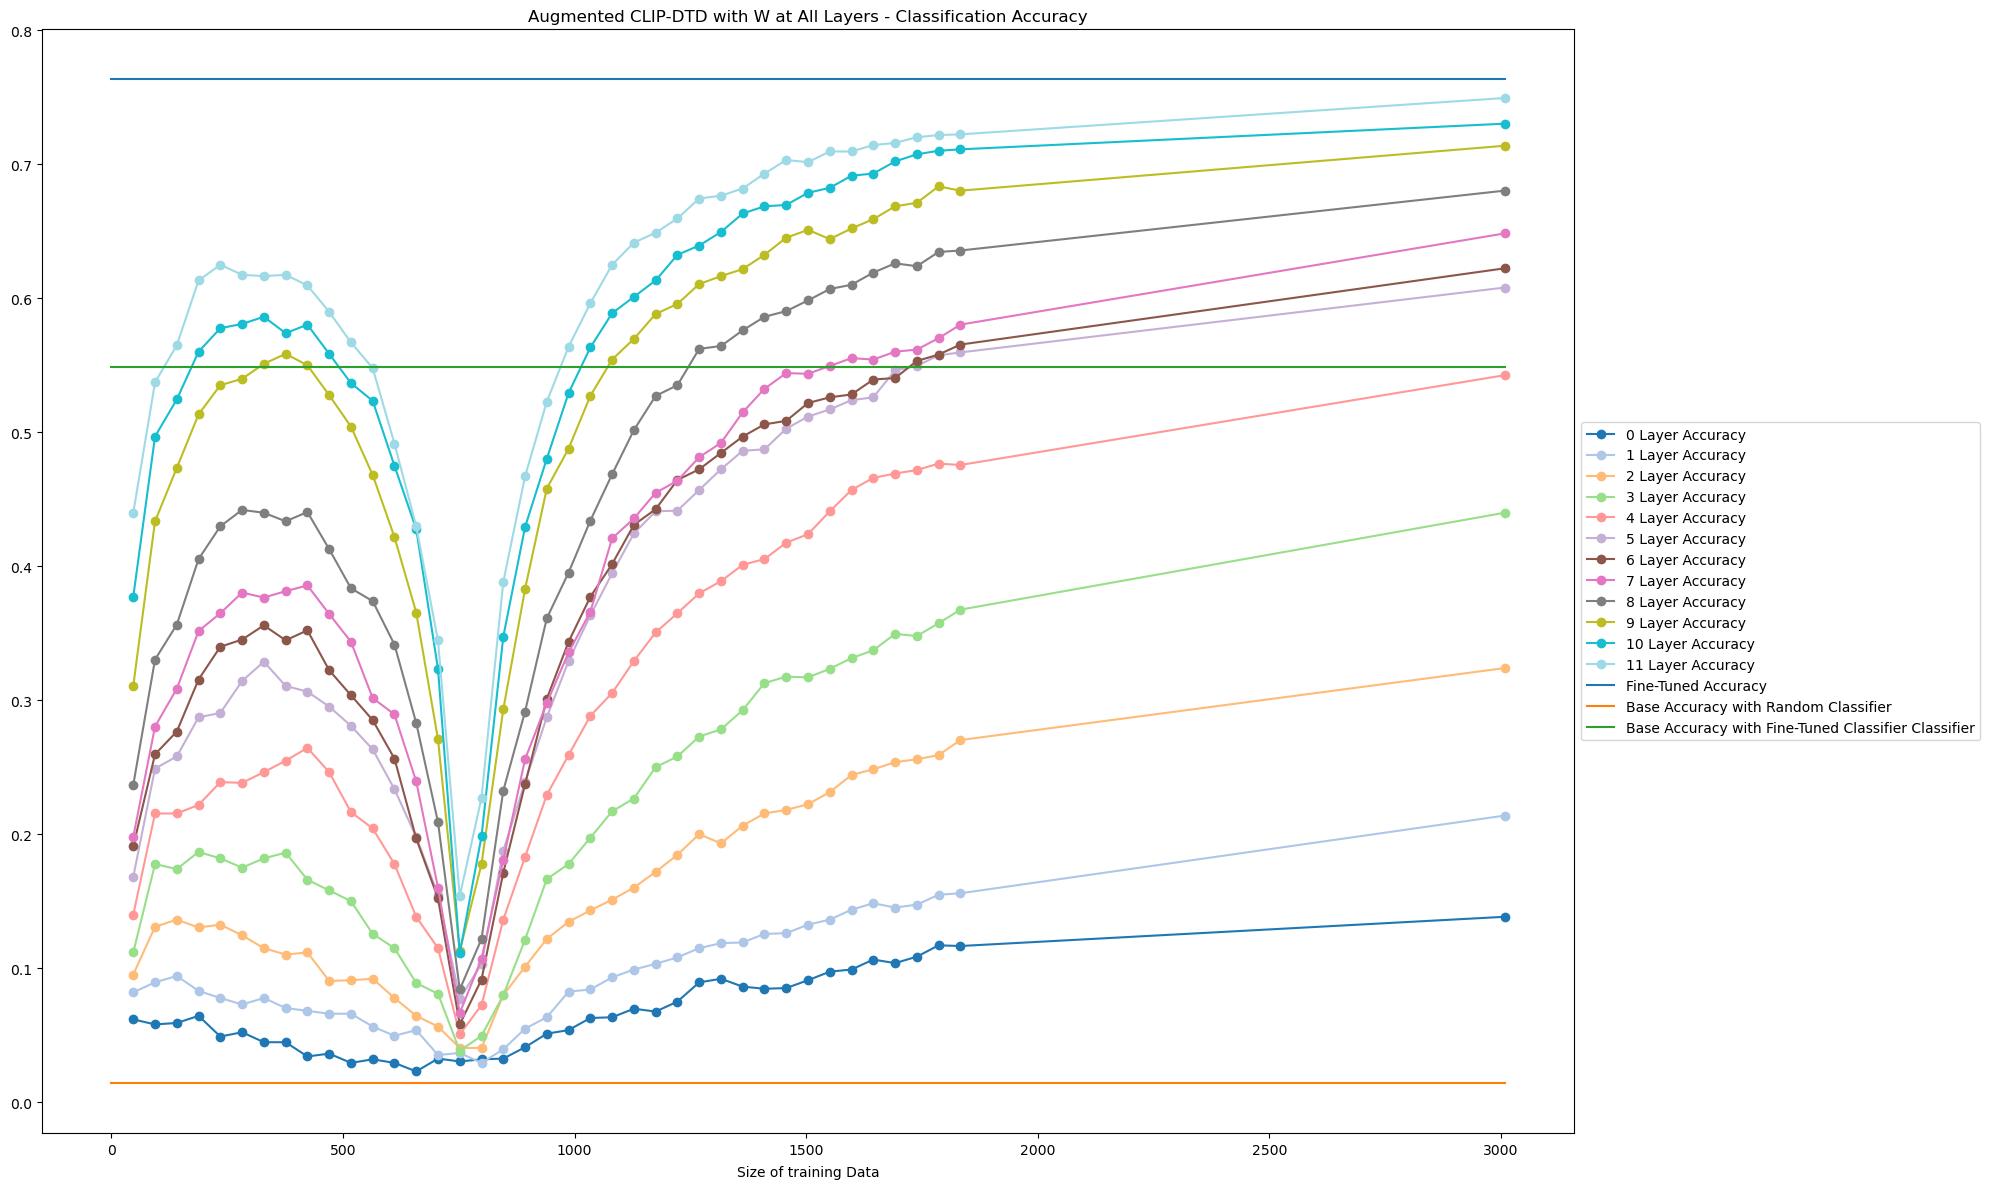

In [10]:
# All Accuracy Together
train_size = []
for i in range(40):
    train_size.append(data[i].loc[0, "Train_Data_Size"])
acc_vals = {}
for i in range(12):
    acc_vals[i] = []
for i in range(12):
    for j in range(40):
        acc_vals[i].append(data[j].loc[i, "Accuracy"])

colors = plt.cm.tab20(np.linspace(0,1,12))
plt.figure(figsize=(20,12))
for i in range(12):
    plt.plot(train_size, acc_vals[i], marker="o", color=colors[i], label=f"{i} Layer Accuracy")
plt.plot([0, 3008], [0.7633, 0.7633], label="Fine-Tuned Accuracy")
plt.plot([0, 3008], [0.0144, 0.0144], label="Base Accuracy with Random Classifier")
plt.plot([0, 3008], [0.5489, 0.5489], label="Base Accuracy with Fine-Tuned Classifier Classifier")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title("Augmented CLIP-DTD with W at All Layers - Classification Accuracy")
plt.xlabel("Size of training Data", labelpad=6)
plt.tight_layout()
# plt.savefig(f'/Users/darrinobrien/Desktop/School/Summer_Programs/Ongoing/Algoverse/Vision/CLIP/DTD/Graphed_Results/All_Augmented_Layers_Classifiction_Accuracy', dpi=600)
plt.show()

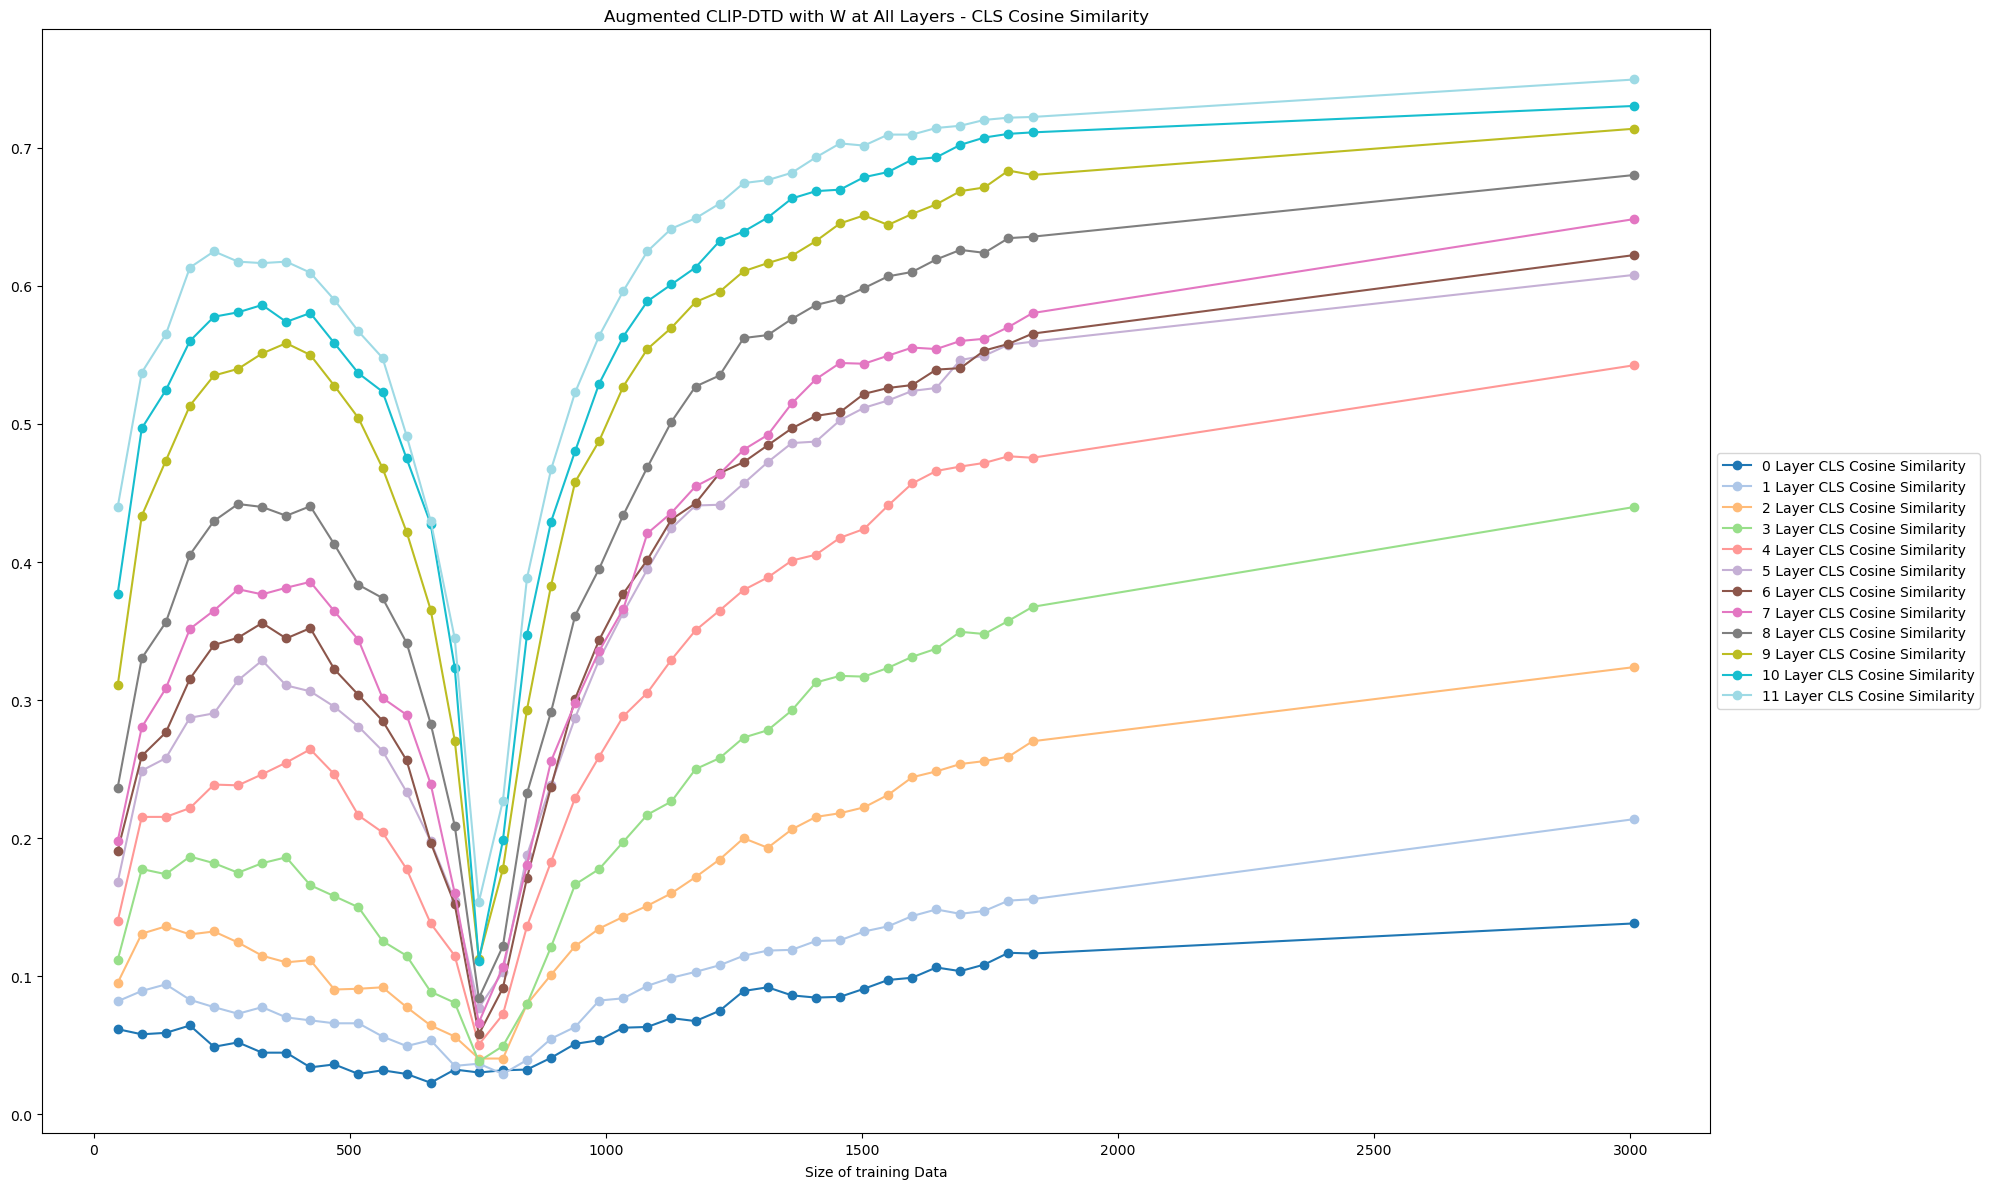

In [10]:
train_size = []
for i in range(40):
    train_size.append(data[i].loc[0, "Train_Data_Size"])
cls_vals = {}
for i in range(12):
    cls_vals[i] = []
for i in range(12):
    for j in range(40):
        cls_vals[i].append(data[j].loc[i, "Co_Sim_CLS"])

colors = plt.cm.tab20(np.linspace(0,1,12))
plt.figure(figsize=(20,12))
for i in range(12):
    plt.plot(train_size, acc_vals[i], marker="o", color=colors[i], label=f"{i} Layer CLS Cosine Similarity")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title("Augmented CLIP-DTD with W at All Layers - CLS Cosine Similarity")
plt.xlabel("Size of training Data", labelpad=6)
plt.tight_layout()
plt.savefig(f'/Users/darrinobrien/Desktop/School/Summer_Programs/Ongoing/Algoverse/Vision/CLIP/DTD/Graphed_Results/All_Augmented_Layers_CLS_Cosine_Similarity', dpi=600)
plt.show()